# EEG exploration and preprocessing — participant 01EDOPEL

**Thesis:** *Analysis of neurophysiological signals for cognitive state assessment in industrial tasks*

This notebook checks the first participant's recording, reviews task markers, filters EEG, and calculates relative band power. The short interim report at the end summarizes the findings and the points to confirm with the supervisor.

Run the notebook from the EEG folder, or from its parent folder. Required packages: NumPy, pandas, SciPy, Matplotlib, and IPython.

## Method and assumptions

- Timestamps are treated as microseconds; their spacing matches the sampling rates in `info.json`.
- Metadata defines marker `value1` as `0 = start`, `1 = end`. In this file, `value2` increases separately for starts and ends; `value3` counts all events. After the extra start, matching only on `value2` would mispair later tasks. Chronological pairing is provisional for segment 10.
- Quality columns are mapped by position to the 12 EEG channels. The meanings of codes 1–4 are not supplied, so they are described without classifying them as good or bad.
- Metadata lists reference `A1` and ground `FPz`. Signal units and any additional referencing during export are not documented in these files.
- The 1–45 Hz bandpass is an initial preprocessing step. No blink/movement correction or channel rejection is applied, so spectral results remain preliminary. See the [MNE artifact overview](https://mne.tools/stable/auto_tutorials/preprocessing/10_preprocessing_overview.html).
- Bands: delta 1–4, theta 4–8, alpha 8–13, beta 13–30, low gamma 30–45 Hz. Gamma above 45 Hz is not analyzed.

## 1. Load and validate the recording

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.signal import butter, sosfiltfilt, welch
from scipy.integrate import trapezoid

DATA_DIR = Path.cwd()
if not (DATA_DIR / "info.json").exists():
    DATA_DIR = DATA_DIR / "EEG"

plt.rcParams.update({"font.size": 10, "figure.dpi": 110})

FILES = {
    "eeg": DATA_DIR / "diadem_eeg.csv",
    "imu": DATA_DIR / "diadem_imu.csv",
    "quality": DATA_DIR / "diadem_quality.csv",
    "markers": DATA_DIR / "userMarker.csv",
    "metadata": DATA_DIR / "info.json",
}
missing = [path.name for path in FILES.values() if not path.exists()]
if missing:
    raise FileNotFoundError(f"Missing required files: {missing}")

with FILES["metadata"].open(encoding="utf-8") as file:
    metadata = json.load(file)

eeg_header = pd.read_csv(FILES["eeg"], nrows=0).columns.tolist()
eeg_channels = [column for column in eeg_header if column.startswith("ch")]
imu_channels = [f"ch{index}" for index in range(1, 10)]

eeg_types = {channel: "float64" for channel in eeg_channels}
eeg_types.update({"sequenceNumber": "int32", "timestamp": "float64", "timestampReception": "float64"})
imu_types = {channel: "float64" for channel in imu_channels}
imu_types.update({"sequenceNumber": "int32", "timestamp": "float64", "timestampReception": "float64"})

eeg = pd.read_csv(FILES["eeg"], dtype=eeg_types)
imu = pd.read_csv(FILES["imu"], dtype=imu_types)
quality = pd.read_csv(FILES["quality"])
markers = pd.read_csv(FILES["markers"])

signal_info = {item["id"]: item for item in metadata["signals"]}
participant_id = signal_info["diadem_eeg"]["subject_id"]
eeg_rate = int(signal_info["diadem_eeg"]["sampling_rate"])
imu_rate = int(signal_info["diadem_imu"]["sampling_rate"])

def validate_stream(name, frame, channels, expected_rate):
    timestamps = frame["timestamp"].to_numpy(dtype="float64")
    steps = np.diff(timestamps)
    if not np.isfinite(timestamps).all():
        raise ValueError(f"{name}: missing or invalid primary timestamps.")
    observed_rate = 1_000_000 / np.median(steps)
    return {
        "stream": name,
        "rows": len(frame),
        "channels": len(channels),
        "duration_min": (timestamps[-1] - timestamps[0]) / 60_000_000,
        "metadata_hz": expected_rate,
        "observed_hz": observed_rate,
        "signal_missing": int(frame[channels].isna().sum().sum()),
        "signal_infinite": int(np.isinf(frame[channels].to_numpy()).sum()),
        "primary_timestamp_missing": int(frame["timestamp"].isna().sum()),
        "reception_timestamp_missing": int(frame["timestampReception"].isna().sum()),
        "duplicate_timestamps": int(pd.Series(timestamps).duplicated().sum()),
        "strictly_increasing": bool(np.all(steps > 0)),
        "regular_sampling": bool(np.all(np.isclose(steps, 1_000_000 / expected_rate, rtol=0, atol=0.01))),
    }

validation = pd.DataFrame([
    validate_stream("EEG", eeg, eeg_channels, eeg_rate),
    validate_stream("IMU", imu, imu_channels, imu_rate),
])

for name, frame in [("markers", markers), ("quality", quality)]:
    if frame.isna().any().any() or not np.isfinite(frame.to_numpy()).all():
        raise ValueError(f"{name}: missing or invalid values.")
    if not np.all(np.diff(frame["timestamp"]) > 0):
        raise ValueError(f"{name}: timestamps are duplicated or unordered.")
    if not frame["timestamp"].between(eeg["timestamp"].iloc[0], eeg["timestamp"].iloc[-1]).all():
        raise ValueError(f"{name}: events outside EEG coverage.")

if not validation["regular_sampling"].all() or not validation["strictly_increasing"].all():
    raise ValueError("Review sample timing before filtering.")
if validation[["signal_missing", "signal_infinite"]].to_numpy().any():
    raise ValueError("Review invalid signal values before filtering.")
if not markers["value1"].isin([0, 1]).all():
    raise ValueError("Unexpected marker code.")

# Split the table to keep the saved output readable.
display(validation[["stream", "rows", "channels", "duration_min", "metadata_hz", "observed_hz"]].round(2))
display(validation[["stream", "signal_missing", "signal_infinite", "primary_timestamp_missing",
                    "reception_timestamp_missing", "duplicate_timestamps", "regular_sampling"]])

,stream,rows,channels,duration_min,metadata_hz,observed_hz
0,EEG,1586984,12,103.32,256,256.0
1,IMU,198373,9,103.32,32,32.0


,stream,signal_missing,signal_infinite,primary_timestamp_missing,reception_timestamp_missing,duplicate_timestamps,regular_sampling
0,EEG,0,0,0,88,0,True
1,IMU,0,0,0,11,0,True


### Missing reception timestamps and packet alignment

In [2]:
# Check packet continuity independently of the regular sample timestamps.
eeg_sequence = eeg["sequenceNumber"].to_numpy()
imu_sequence = imu["sequenceNumber"].to_numpy()
samples_per_packet = int(signal_info["diadem_eeg"]["num_elements"])
assert len(eeg) == samples_per_packet * len(imu), "Unexpected EEG/IMU row ratio."
assert np.all(np.diff(imu_sequence) == 1), "Review IMU sequence gaps."
assert np.array_equal(eeg_sequence, np.repeat(imu_sequence, samples_per_packet)), "Review packet alignment."
assert np.allclose(eeg["timestamp"].to_numpy()[::samples_per_packet],
                   imu["timestamp"].to_numpy(), rtol=0, atol=0.01), "Review EEG/IMU timing."
print(f"{len(imu):,} aligned packets; each contains {samples_per_packet} EEG samples and one IMU sample.")

assert np.array_equal(eeg["timestampReception"].isna().to_numpy(),
                      np.repeat(imu["timestampReception"].isna().to_numpy(), samples_per_packet)), "Reception gaps differ between streams."

# Group consecutive missing reception timestamps. CSV line 1 is the header.
recording_start = eeg["timestamp"].iloc[0]
missing_rows = []
for name, frame in [("EEG", eeg), ("IMU", imu)]:
    indices = np.flatnonzero(frame["timestampReception"].isna())
    for run in np.split(indices, np.flatnonzero(np.diff(indices) > 1) + 1):
        if len(run) == 0:
            continue
        first, last = frame.iloc[run[0]], frame.iloc[run[-1]]
        missing_rows.append({
            "stream": name,
            "csv_first_line": int(run[0] + 2),
            "csv_last_line": int(run[-1] + 2),
            "missing_values": len(run),
            "start_s": (first["timestamp"] - recording_start) / 1e6,
            "end_s": (last["timestamp"] - recording_start) / 1e6,
        })
missing_reception = pd.DataFrame(missing_rows)
display(missing_reception.round(3))
print("Times are seconds from the first EEG sample. No reception timestamps are filled or interpolated.")

198,373 aligned packets; each contains 8 EEG samples and one IMU sample.


,stream,csv_first_line,csv_last_line,missing_values,start_s,end_s
0,EEG,327770,327833,64,1280.344,1280.590
1,EEG,328362,328369,8,1282.656,1282.684
2,EEG,328410,328425,16,1282.844,1282.902
3,IMU,40973,40980,8,1280.344,1280.562
4,IMU,41047,41047,1,1282.656,1282.656
5,IMU,41053,41054,2,1282.844,1282.875


Times are seconds from the first EEG sample. No reception timestamps are filled or interpolated.


## 2. Pair task markers and expose protocol issues

,segment,duration_s,gap_before_s,gap_status,boundary_status
0,1,301.87,NaN,not_applicable,paired
1,2,307.84,1034.59,major_protocol_gap,paired
2,3,253.38,14.56,typical,paired
3,4,236.47,17.25,typical,paired
4,5,229.41,17.97,typical,paired
5,6,324.34,15.31,typical,paired
6,7,227.19,14.16,typical,paired
7,8,226.50,16.28,typical,paired
8,9,231.22,15.81,typical,paired
9,10,267.28,28.31,statistical_outlier,review_required


,issue,marker_number,counter,timestamp
0,repeated_start,20,11,1.153537e+10


,segment,start_marker,end_marker,duration_s,alternative_duration_s
9,10,19,21,267.28,228.47


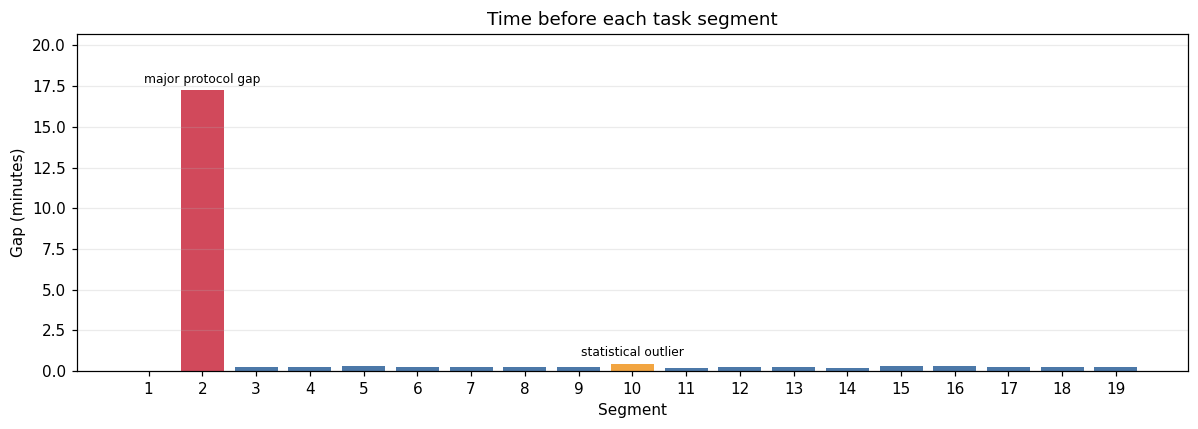

In [3]:
def pair_markers(events):
    pairs, issues = [], []
    open_start, repeated_starts = None, []

    for row_number, row in events.reset_index(drop=True).iterrows():
        marker_number = row_number + 1
        event_code = int(row["value1"])
        event = {
            "marker_number": marker_number,
            "counter": int(row["value2"]),
            "timestamp": float(row["timestamp"]),
        }

        if event_code == 0:
            if open_start is None:
                open_start, repeated_starts = event, []
            else:
                repeated_starts.append(event)
                issues.append({"issue": "repeated_start", **event})
        elif event_code == 1 and open_start is not None:
            alternative = repeated_starts[0] if repeated_starts else None
            pairs.append({
                "segment": len(pairs) + 1,
                "start_marker": open_start["marker_number"],
                "end_marker": event["marker_number"],
                "start_timestamp": open_start["timestamp"],
                "end_timestamp": event["timestamp"],
                "duration_s": (event["timestamp"] - open_start["timestamp"]) / 1_000_000,
                "start_counter": open_start["counter"],
                "end_counter": event["counter"],
                "alternative_start_timestamp": alternative["timestamp"] if alternative else np.nan,
                "alternative_duration_s": ((event["timestamp"] - alternative["timestamp"]) / 1_000_000) if alternative else np.nan,
                "boundary_status": "review_required" if alternative else "paired",
            })
            open_start, repeated_starts = None, []
        elif event_code == 1:
            issues.append({"issue": "orphan_end", **event})
        else:
            issues.append({"issue": "unknown_code", **event})

    if open_start is not None:
        issues.append({"issue": "unmatched_start", **open_start})

    segments = pd.DataFrame(pairs)
    segments["gap_before_s"] = (
        segments["start_timestamp"] - segments["end_timestamp"].shift()
    ) / 1_000_000

    gaps = segments["gap_before_s"].dropna()
    outlier_limit = gaps.quantile(0.75) + 1.5 * (gaps.quantile(0.75) - gaps.quantile(0.25))
    segments["gap_status"] = np.select(
        [segments["gap_before_s"] > 300, segments["gap_before_s"] > outlier_limit],
        ["major_protocol_gap", "statistical_outlier"],
        default="typical",
    )
    segments.loc[segments["gap_before_s"].isna(), "gap_status"] = "not_applicable"
    return segments, pd.DataFrame(issues)

segments, marker_issues = pair_markers(markers)
assert (segments["duration_s"] > 0).all(), "A segment has non-positive duration."
assert (segments["gap_before_s"].dropna() >= 0).all(), "Segments overlap."
gap_start = (segments.loc[0, "end_timestamp"] - recording_start) / 1e6
gap_end = (segments.loc[1, "start_timestamp"] - recording_start) / 1e6
assert (missing_reception["start_s"] > gap_start).all() and (missing_reception["end_s"] < gap_end).all()
assert len(markers) == 2 * len(segments) + len(marker_issues), "Review unaccounted marker events."

display(segments[["segment", "duration_s", "gap_before_s", "gap_status", "boundary_status"]].round(2))
display(marker_issues)
ambiguous = segments[segments["boundary_status"] == "review_required"]
display(ambiguous[["segment", "start_marker", "end_marker", "duration_s", "alternative_duration_s"]].round(2))

gap_colors = segments["gap_status"].map({
    "not_applicable": "#bdbdbd",
    "typical": "#4c78a8",
    "statistical_outlier": "#f2a541",
    "major_protocol_gap": "#d1495b",
})
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(segments["segment"], segments["gap_before_s"].fillna(0) / 60, color=gap_colors)
ax.set(title="Time before each task segment", xlabel="Segment", ylabel="Gap (minutes)")
ax.set_xticks(segments["segment"])
ax.set_ylim(0, segments["gap_before_s"].max() / 60 * 1.2)
ax.grid(axis="y", alpha=0.25)
for row in segments.loc[segments["gap_status"].isin(["major_protocol_gap", "statistical_outlier"])].itertuples():
    ax.annotate(row.gap_status.replace("_", " "), (row.segment, row.gap_before_s / 60), xytext=(0, 5), textcoords="offset points", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

The file contains 20 starts and 19 ends. Segment 10 has starts at **3520.659 s** and **3559.471 s**, followed by an end at **3787.938 s** from recording start (`userMarker.csv` lines **20, 21, and 22**). The durations are **267.28 s** or **228.47 s**. The first start is used provisionally; both choices are compared below. Original markers are unchanged.

The **1034.59 s (17.24 min)** interval before segment 2 is a gap between task markers, not a gap in EEG samples. All missing reception timestamps occur within that interval. Its experimental meaning cannot be determined from these files. The 28.31 s interval before segment 10 is an IQR outlier, but that alone does not make it an error.

## 3. Describe device quality codes

,code_1_pct,code_2_pct,code_3_pct,code_4_pct
channel,,,,
ch1-AF7,99.51,0.16,0.33,0.00
ch2-Fp1,99.35,0.33,0.33,0.00
ch3-Fp2,99.35,0.33,0.33,0.00
ch4-AF8,99.18,0.49,0.33,0.00
ch5-F3,80.97,2.29,13.03,3.72
ch6-F4,86.32,5.88,7.35,0.45
ch7-P3,98.98,0.69,0.33,0.00
ch8-P4,96.33,2.98,0.69,0.00
ch9-P7,99.14,0.53,0.33,0.00


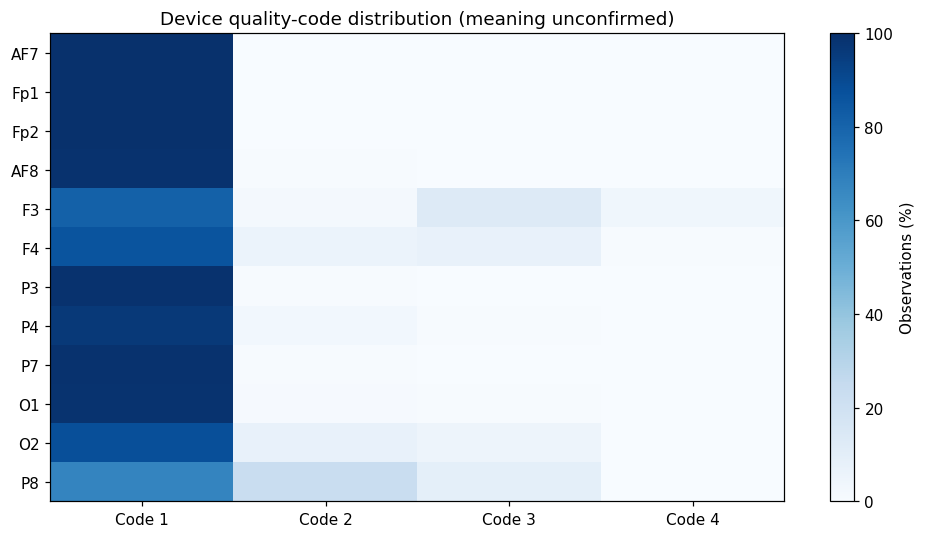

In [4]:
quality_columns = [f"value{index}" for index in range(1, 13)]
quality_map = dict(zip(quality_columns, eeg_channels))
assert quality[quality_columns].isin([1, 2, 3, 4]).all().all(), "Unexpected quality code."

quality_summary = pd.DataFrame({
    channel: quality[value_column].value_counts(normalize=True).mul(100)
    for value_column, channel in quality_map.items()
}).T.reindex(columns=[1, 2, 3, 4], fill_value=0).fillna(0)
quality_summary.columns = [f"code_{code}_pct" for code in quality_summary.columns]
quality_summary.index.name = "channel"

display(quality_summary.round(2))
fig, ax = plt.subplots(figsize=(9, 5))
image = ax.imshow(quality_summary, aspect="auto", cmap="Blues", vmin=0, vmax=100)
ax.set_xticks(range(4), ["Code 1", "Code 2", "Code 3", "Code 4"])
ax.set_yticks(range(len(eeg_channels)), [channel.split("-", 1)[-1] for channel in eeg_channels])
ax.set_title("Device quality-code distribution (meaning unconfirmed)")
fig.colorbar(image, ax=ax, label="Observations (%)")
plt.tight_layout()
plt.show()

## 4. Inspect signal extremes and filter EEG

This check counts samples within 0.5% of the full observed range from the global minimum or maximum. It is only a way to locate extremes: the observed range is not a known hardware limit, and this does not establish clipping. No samples are removed on this basis.

,channel,minimum,maximum,samples_near_lower,samples_near_upper,percentage_near_extremes,near_extreme_flag
4,ch5-F3,-102070.0389,98304.4774,691,0,0.0435,True
5,ch6-F4,-102070.0389,97962.2001,227,0,0.0143,True
6,ch7-P3,24074.5912,102070.0267,0,2,0.0001,True
8,ch9-P7,21121.6251,101923.1748,0,2,0.0001,True
9,ch10-O1,13681.2731,102070.0267,0,1,0.0001,True


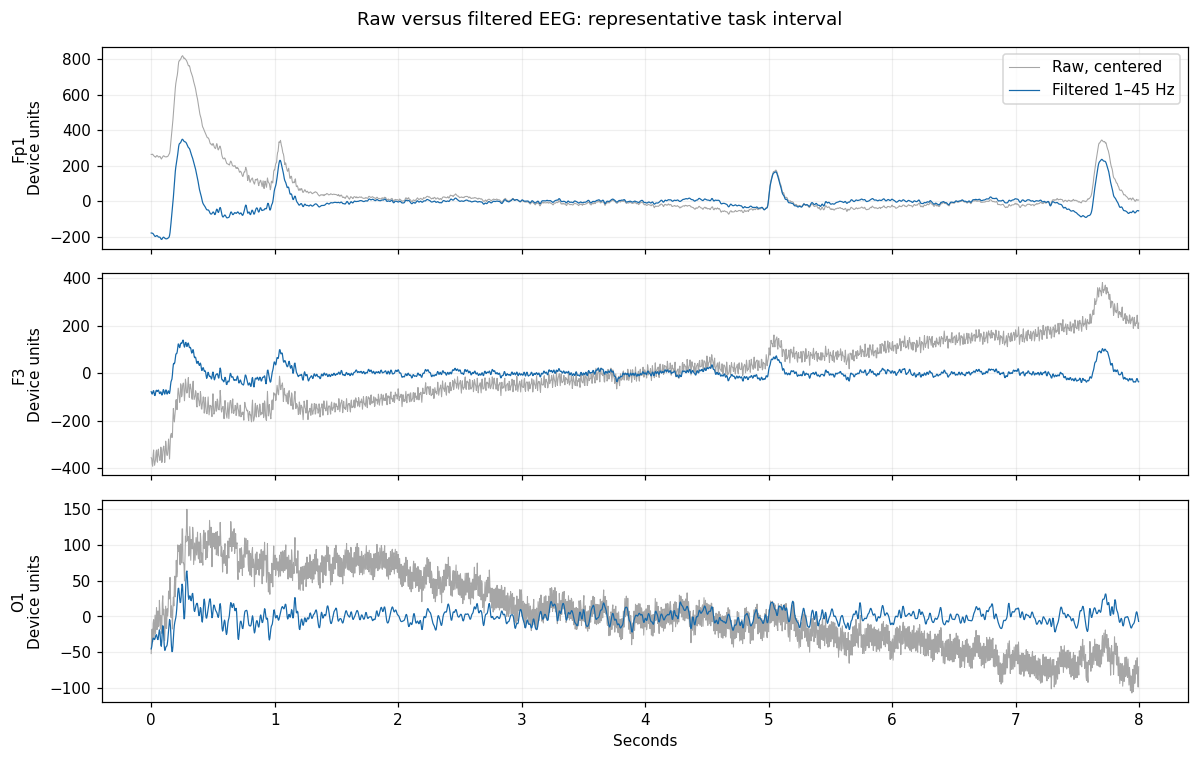

In [5]:
LOW_HZ, HIGH_HZ, FILTER_ORDER = 1.0, 45.0, 4
bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "low_gamma": (30, 45),
}

filter_sos = butter(
    FILTER_ORDER,
    [LOW_HZ, HIGH_HZ],
    btype="bandpass",
    fs=eeg_rate,
    output="sos",
)
raw_eeg = eeg[eeg_channels].to_numpy(dtype="float64", copy=True)

# Locate extremes for review; these are not confirmed device limits.
observed_min, observed_max = float(np.nanmin(raw_eeg)), float(np.nanmax(raw_eeg))
boundary_tolerance = 0.005 * (observed_max - observed_min)
boundary_rows = []
for channel_index, channel in enumerate(eeg_channels):
    values = raw_eeg[:, channel_index]
    near_lower = int(np.sum(values <= observed_min + boundary_tolerance))
    near_upper = int(np.sum(values >= observed_max - boundary_tolerance))
    boundary_rows.append({
        "channel": channel,
        "minimum": float(np.min(values)),
        "maximum": float(np.max(values)),
        "samples_near_lower": near_lower,
        "samples_near_upper": near_upper,
        "percentage_near_extremes": 100 * (near_lower + near_upper) / len(values),
        "near_extreme_flag": (near_lower + near_upper) > 0,
    })
boundary_summary = pd.DataFrame(boundary_rows)
display(boundary_summary.loc[boundary_summary["near_extreme_flag"]].round(4))

filtered_eeg = sosfiltfilt(filter_sos, raw_eeg, axis=0)
assert np.isfinite(filtered_eeg).all(), "Filtering produced invalid values."

preview_channels = ["ch2-Fp1", "ch5-F3", "ch10-O1"]
preview_start = np.searchsorted(eeg["timestamp"].to_numpy(), segments.loc[0, "start_timestamp"]) + 5 * eeg_rate
preview_stop = preview_start + 8 * eeg_rate
preview_time = np.arange(preview_stop - preview_start) / eeg_rate

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for axis, channel in zip(axes, preview_channels):
    channel_index = eeg_channels.index(channel)
    raw_trace = raw_eeg[preview_start:preview_stop, channel_index].astype("float64")
    raw_trace -= np.median(raw_trace)
    axis.plot(preview_time, raw_trace, color="0.65", linewidth=0.7, label="Raw, centered")
    axis.plot(preview_time, filtered_eeg[preview_start:preview_stop, channel_index], color="#1769aa", linewidth=0.8, label="Filtered 1–45 Hz")
    axis.set_ylabel(f"{channel.split('-', 1)[-1]}\nDevice units")
    axis.grid(alpha=0.2)

axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Seconds")
fig.suptitle("Raw versus filtered EEG: representative task interval")
plt.tight_layout()
plt.show()

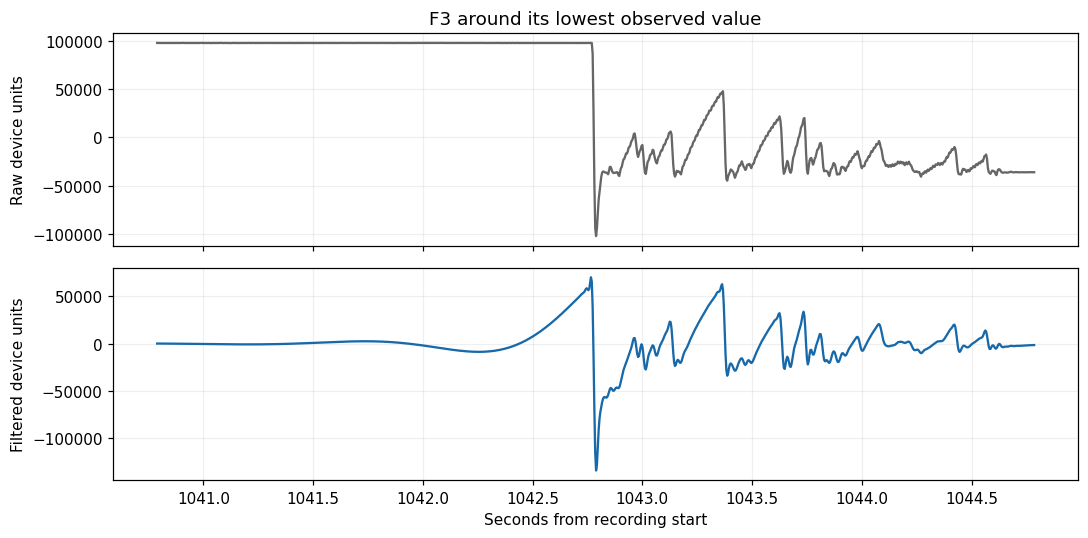

In [6]:
# Inspect a second interval around the lowest F3 value.
channel_index = eeg_channels.index("ch5-F3")
center = int(np.argmin(raw_eeg[:, channel_index]))
left, right = max(0, center - 2 * eeg_rate), min(len(eeg), center + 2 * eeg_rate)
seconds = (eeg["timestamp"].to_numpy()[left:right] - recording_start) / 1e6
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(seconds, raw_eeg[left:right, channel_index], color="0.4")
axes[0].set(title="F3 around its lowest observed value", ylabel="Raw device units")
axes[1].plot(seconds, filtered_eeg[left:right, channel_index], color="#1769aa")
axes[1].set(xlabel="Seconds from recording start", ylabel="Filtered device units")
for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

The inspected F3 excursion occurs around **1043 seconds**, during the interval between tasks 1 and 2. It remains large after filtering. In the earlier task preview, short transients also remain visible in Fp1. These examples show why the filter output still needs artifact review; the plots alone do not identify the cause of each transient.

## 5. Calculate descriptive relative band power

Welch PSD uses four-second Hann windows, 50% overlap, constant detrending, and median averaging. Band power is integrated and divided by total 1–45 Hz power for each channel, then relative powers are averaged across channels. The shared band-edge points do not double-count frequency intervals with trapezoidal integration. See the [SciPy Welch documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.welch.html).

The plot includes all channels and provisional segment 10. It describes the filtered recording; it is not an artifact-free estimate of cognitive state.

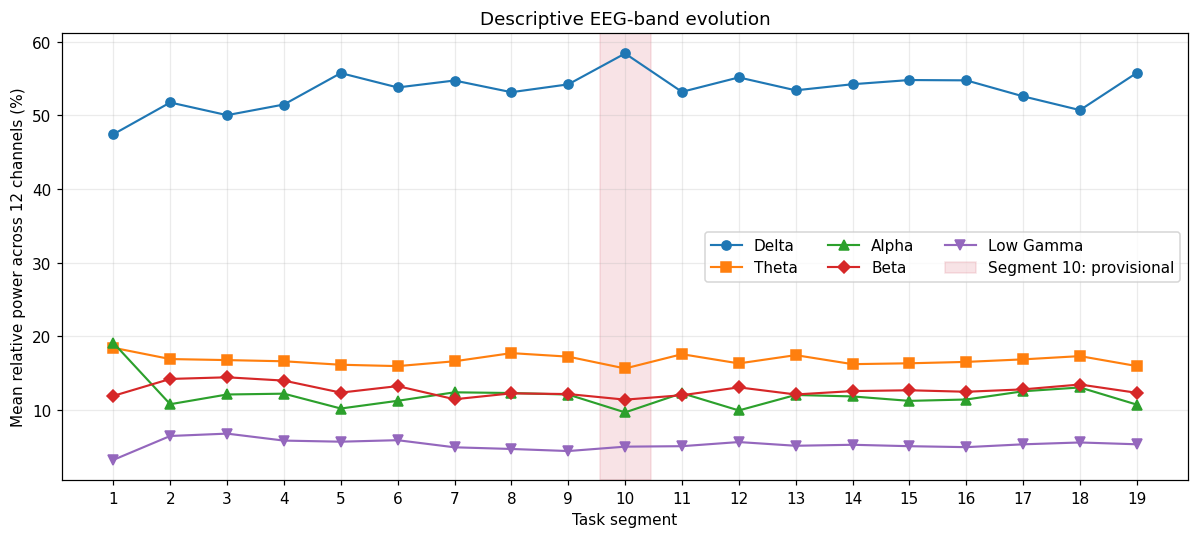

In [7]:
timestamps = eeg["timestamp"].to_numpy(dtype="float64")
window_samples = 4 * eeg_rate
bandpower_rows = []

def segment_psd(start_timestamp, end_timestamp):
    start = np.searchsorted(timestamps, start_timestamp)
    stop = np.searchsorted(timestamps, end_timestamp, side="right")
    if stop - start < window_samples:
        raise ValueError("Segment is shorter than the PSD window.")
    return welch(
        filtered_eeg[start:stop], fs=eeg_rate, window="hann",
        nperseg=window_samples, noverlap=window_samples // 2,
        detrend="constant", scaling="density", average="median", axis=0,
    )

segment_spectra = {}
for segment in segments.itertuples(index=False):
    frequencies, psd = segment_psd(segment.start_timestamp, segment.end_timestamp)
    segment_spectra[segment.segment] = psd
    total_mask = (frequencies >= LOW_HZ) & (frequencies <= HIGH_HZ)
    total_power = trapezoid(psd[total_mask], frequencies[total_mask], axis=0)

    for band, (low, high) in bands.items():
        mask = (frequencies >= low) & (frequencies <= high)
        power = trapezoid(psd[mask], frequencies[mask], axis=0)
        relative_power = np.divide(power, total_power, out=np.full_like(power, np.nan), where=total_power > 0)
        for channel, value in zip(eeg_channels, relative_power):
            bandpower_rows.append({
                "participant": participant_id,
                "segment": segment.segment,
                "segment_status": segment.boundary_status,
                "channel": channel.split("-", 1)[-1],
                "band": band,
                "relative_power": value,
            })

bandpower_channel = pd.DataFrame(bandpower_rows)
bandpower_segment = (
    bandpower_channel.groupby(["participant", "segment", "segment_status", "band"], as_index=False)
    ["relative_power"].mean()
)

# Each channel's five bands should account for its total 1–45 Hz power.
assert len(bandpower_channel) == len(segments) * len(eeg_channels) * len(bands)
assert np.isfinite(bandpower_channel["relative_power"]).all()
assert bandpower_channel["relative_power"].between(0, 1).all()
assert np.allclose(bandpower_channel.groupby(["segment", "channel"])["relative_power"].sum(), 1)

fig, ax = plt.subplots(figsize=(11, 5))
for band, marker in zip(bands, ["o", "s", "^", "D", "v"]):
    values = bandpower_segment[bandpower_segment["band"] == band]
    ax.plot(values["segment"], 100 * values["relative_power"], marker=marker, linewidth=1.4, label=band.replace("_", " ").title())

for segment_id in segments.loc[segments["boundary_status"] == "review_required", "segment"]:
    ax.axvspan(segment_id - 0.45, segment_id + 0.45, color="#d1495b", alpha=0.15, label="Segment 10: provisional")

ax.set(title="Descriptive EEG-band evolution", xlabel="Task segment", ylabel="Mean relative power across 12 channels (%)")
ax.set_xticks(segments["segment"])
ax.grid(alpha=0.25)
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

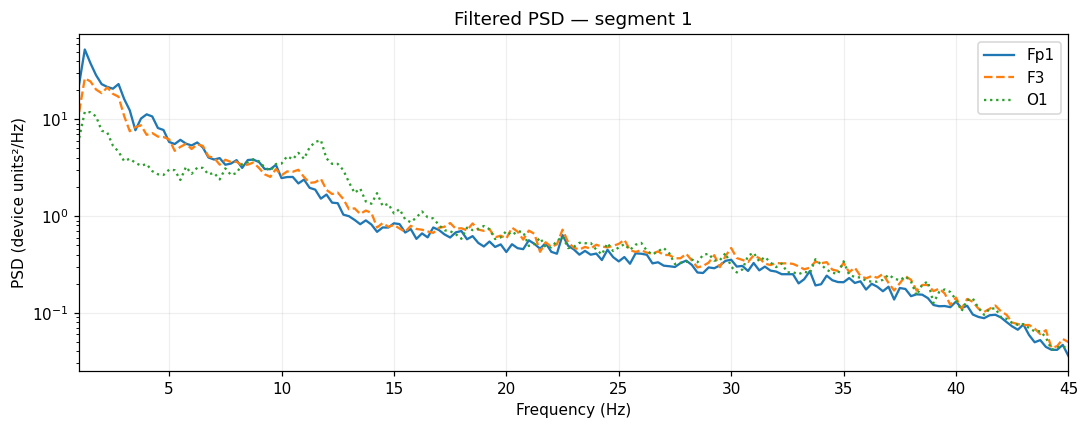

,band,first_start_pct,second_start_pct,difference_pp
0,delta,58.39,58.54,0.16
1,theta,15.61,15.43,-0.18
2,alpha,9.64,9.48,-0.17
3,beta,11.37,11.55,0.18
4,low_gamma,4.99,5.00,0.01


Difference is second minus first start, in percentage points, averaged across 12 channels.


In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
mask = (frequencies >= LOW_HZ) & (frequencies <= HIGH_HZ)
for channel, style in zip(preview_channels, ["-", "--", ":"]):
    index = eeg_channels.index(channel)
    ax.semilogy(frequencies[mask], segment_spectra[1][mask, index],
                linestyle=style, label=channel.split("-", 1)[-1])
ax.set(title="Filtered PSD — segment 1", xlabel="Frequency (Hz)",
       ylabel="PSD (device units²/Hz)", xlim=(1, 45))
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Quantify the effect of the uncertain start without deciding which is correct.
sensitivity_rows = []
for segment in ambiguous.itertuples(index=False):
    alt_frequencies, alt_psd = segment_psd(segment.alternative_start_timestamp, segment.end_timestamp)
    total_mask = (alt_frequencies >= LOW_HZ) & (alt_frequencies <= HIGH_HZ)
    alt_total = trapezoid(alt_psd[total_mask], alt_frequencies[total_mask], axis=0)
    for band, (low, high) in bands.items():
        mask = (alt_frequencies >= low) & (alt_frequencies <= high)
        alt_power = trapezoid(alt_psd[mask], alt_frequencies[mask], axis=0) / alt_total
        original = bandpower_segment.loc[(bandpower_segment["segment"] == segment.segment)
                                        & (bandpower_segment["band"] == band), "relative_power"].iloc[0]
        sensitivity_rows.append({"band": band, "first_start_pct": 100 * original,
                                 "second_start_pct": 100 * alt_power.mean(),
                                 "difference_pp": 100 * (alt_power.mean() - original)})
marker_sensitivity = pd.DataFrame(sensitivity_rows)
display(marker_sensitivity.round(2))
print("Difference is second minus first start, in percentage points, averaged across 12 channels.")

## Interim report for the supervisor

In [9]:
eeg_result = validation.iloc[0]
max_marker_change = marker_sensitivity["difference_pp"].abs().max()

report = f"""# Interim EEG analysis report

**Participant:** {participant_id}

I checked the first participant's EEG recording, the movement-sensor data, the quality codes, and the task markers.

**Recording and timestamps.** The recording contains {eeg_result['duration_min']:.2f} minutes of 12-channel EEG at 256 Hz and nine-channel IMU at 32 Hz. There are no missing signal values or primary timestamps, and sample spacing is regular. The {len(imu):,} packet sequence numbers are continuous and aligned between EEG and IMU. This check did not find missing sample rows in the exported files.

There are **88 missing EEG reception timestamps and 11 missing IMU reception timestamps**, in the same 11 packets. They occur about **21 min 20–23 s** after recording start, between tasks 1 and 2. Their exact locations are listed below. The sample timestamps and signal values are present, so I have not interpolated or deleted these rows.

**Task markers.** I obtained 19 candidate task segments. Segment 10 contains two start markers, 38.81 seconds apart (`userMarker.csv` lines 20 and 21), before one end marker (line 22). Using the first start gives 267.28 seconds; the second gives 228.47 seconds. I kept the first start provisionally and compared both choices: the largest change in the channel-averaged relative band powers is **{max_marker_change:.2f} percentage points**. This comparison does not resolve which start is correct. There is also a **17.24-minute interval between tasks 1 and 2**; EEG and IMU samples continue through it.

**Preprocessing and initial findings.** I applied a 1–45 Hz bandpass filter and calculated Welch PSD and relative delta, theta, alpha, beta, and low-gamma power for each segment and channel. P8 has the lowest proportion of quality code 1 (67.37%); the code meanings are still unconfirmed. F3 and F4 contain most samples near the overall observed amplitude extremes, which are not confirmed hardware limits. No channels or intervals have been rejected, and blink/movement artifacts have not been separately corrected. The current plots are preliminary and do not establish fatigue, workload, or learning.

**Points to confirm.** Which start should be used for segment 10, and what happened during the long interval between tasks 1 and 2? Please also confirm the quality-code meanings, signal units, and whether the exported signal uses the A1 reference listed in the metadata. These details will help finalize preprocessing before applying it to the remaining participants.
"""

# Include exact CSV locations without adding a separate technical appendix.
location_table = "| File | CSV lines (header is line 1) | Missing values | Seconds from EEG start |\n"
location_table += "|---|---:|---:|---:|\n"
for row in missing_reception.itertuples(index=False):
    filename = "diadem_eeg.csv" if row.stream == "EEG" else "diadem_imu.csv"
    location_table += (f"| {filename} | {row.csv_first_line}–{row.csv_last_line} | "
                       f"{row.missing_values} | {row.start_s:.3f}–{row.end_s:.3f} |\n")
report += "\n**Missing reception timestamp locations**\n\n" + location_table
(DATA_DIR / "interim_report_01EDOPEL.md").write_text(report.strip() + "\n", encoding="utf-8")
display(Markdown(report))

# Interim EEG analysis report

**Participant:** 01EDOPEL

I checked the first participant's EEG recording, the movement-sensor data, the quality codes, and the task markers.

**Recording and timestamps.** The recording contains 103.32 minutes of 12-channel EEG at 256 Hz and nine-channel IMU at 32 Hz. There are no missing signal values or primary timestamps, and sample spacing is regular. The 198,373 packet sequence numbers are continuous and aligned between EEG and IMU. This check did not find missing sample rows in the exported files.

There are **88 missing EEG reception timestamps and 11 missing IMU reception timestamps**, in the same 11 packets. They occur about **21 min 20–23 s** after recording start, between tasks 1 and 2. Their exact locations are listed below. The sample timestamps and signal values are present, so I have not interpolated or deleted these rows.

**Task markers.** I obtained 19 candidate task segments. Segment 10 contains two start markers, 38.81 seconds apart (`userMarker.csv` lines 20 and 21), before one end marker (line 22). Using the first start gives 267.28 seconds; the second gives 228.47 seconds. I kept the first start provisionally and compared both choices: the largest change in the channel-averaged relative band powers is **0.18 percentage points**. This comparison does not resolve which start is correct. There is also a **17.24-minute interval between tasks 1 and 2**; EEG and IMU samples continue through it.

**Preprocessing and initial findings.** I applied a 1–45 Hz bandpass filter and calculated Welch PSD and relative delta, theta, alpha, beta, and low-gamma power for each segment and channel. P8 has the lowest proportion of quality code 1 (67.37%); the code meanings are still unconfirmed. F3 and F4 contain most samples near the overall observed amplitude extremes, which are not confirmed hardware limits. No channels or intervals have been rejected, and blink/movement artifacts have not been separately corrected. The current plots are preliminary and do not establish fatigue, workload, or learning.

**Points to confirm.** Which start should be used for segment 10, and what happened during the long interval between tasks 1 and 2? Please also confirm the quality-code meanings, signal units, and whether the exported signal uses the A1 reference listed in the metadata. These details will help finalize preprocessing before applying it to the remaining participants.

**Missing reception timestamp locations**

| File | CSV lines (header is line 1) | Missing values | Seconds from EEG start |
|---|---:|---:|---:|
| diadem_eeg.csv | 327770–327833 | 64 | 1280.344–1280.590 |
| diadem_eeg.csv | 328362–328369 | 8 | 1282.656–1282.684 |
| diadem_eeg.csv | 328410–328425 | 16 | 1282.844–1282.902 |
| diadem_imu.csv | 40973–40980 | 8 | 1280.344–1280.562 |
| diadem_imu.csv | 41047–41047 | 1 | 1282.656–1282.656 |
| diadem_imu.csv | 41053–41054 | 2 | 1282.844–1282.875 |
